<a href="https://colab.research.google.com/github/Fluvia20079668/Flu01/blob/main/BA26_0633_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 1 .Environment Setup
imports all the required Python libraries. It brings in libraries for data handling, text
cleaning, machine learning, deep learning, visualisation, and file saving.

In [1]:
import os
import re #regex, for text cleaning and pattern matching
import tarfile
import zipfile
import gzip
import urllib.request
import shutil #file/path handling
import random
import warnings
import pickle # saving/loading data
import json
from pathlib import Path
from collections import Counter #word frequency counting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer #converts text into TF-IDF numerical vectors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder #encodes text labels into integers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight # for handling imbalanced classes

try:
    import scipy.io as sio
    import scipy.sparse as sp
except Exception:
    sio = None
    sp = None

try:
    import tensorflow as tf # Trasflow used for nural network--Bi_lstm
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
except Exception:
    tf = None

warnings.filterwarnings("ignore")
# random seed to make experiment reproducible.
random.seed(42)
np.random.seed(42)

if tf is not None:
    tf.random.set_seed(42)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 250)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2.Dataset Loading Settings

It sets the folder where the raw dataset, processed files,
figures and models will be stored. It also sets options such as file paths, maximum rows and
random state.

In [2]:

DATA_SOURCE_PATH = ""
DIRECT_DOWNLOAD_URL = ""
SCI_DB_PAGE_URL = "https://www.scidb.cn/en/detail?dataSetId=43d7f503936f45acafc2864f6573237b"
MANUAL_SELECTED_FILE = ""

MAX_LOAD_ROWS = 250000
MODEL_SAMPLE_ROWS = 60000
RANDOM_STATE = 42

work_dir = Path("/content/yelp_fake_review_project")
raw_dir = work_dir / "raw"
processed_dir = work_dir / "processed"
model_dir = work_dir / "models"
figure_dir = work_dir / "figures"

#Create these folders if they don't already exist.

for folder in [raw_dir, processed_dir, model_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

settings_summary = pd.DataFrame({
    "setting": ["DATA_SOURCE_PATH", "DIRECT_DOWNLOAD_URL", "SCI_DB_PAGE_URL", "MAX_LOAD_ROWS", "MODEL_SAMPLE_ROWS"],
    "value": [DATA_SOURCE_PATH, DIRECT_DOWNLOAD_URL, SCI_DB_PAGE_URL, MAX_LOAD_ROWS, MODEL_SAMPLE_ROWS]
})

settings_summary

,setting,value
0,DATA_SOURCE_PATH,
1,DIRECT_DOWNLOAD_URL,
2,SCI_DB_PAGE_URL,https://www.scidb.cn/en/detail?dataSetId=43d7f503936f45acafc2864f6573237b
3,MAX_LOAD_ROWS,250000
4,MODEL_SAMPLE_ROWS,60000


## 3.Dataset Upload or Download
upload the dataset manually or load it from a given file path. It
is useful in Google Colab because datasets are often uploaded directly or taken from Google Drive.

In [3]:
try:
    from google.colab import files
    colab_available = True
except Exception:
    files = None
    colab_available = False

def download_file(url, destination_folder):
    destination_folder = Path(destination_folder)
    destination_folder.mkdir(parents=True, exist_ok=True)
    file_name = url.split("/")[-1].split("?")[0] # extract the file name from URL
    if file_name.strip() == "":
        file_name = "downloaded_dataset"
    destination_path = destination_folder / file_name
    urllib.request.urlretrieve(url, destination_path) #downloads the file
    return destination_path

if DATA_SOURCE_PATH.strip():
    data_source = Path(DATA_SOURCE_PATH)
elif DIRECT_DOWNLOAD_URL.strip():
    data_source = download_file(DIRECT_DOWNLOAD_URL, raw_dir)
elif colab_available:
    uploaded = files.upload()
    data_source = Path(next(iter(uploaded.keys())))
else:
    data_source = None

data_source

Saving yelpzip.csv to yelpzip.csv


PosixPath('yelpzip.csv')

## 4.Dataset Extraction
uploaded file is compressed so such as a ZIP or TAR file. If the dataset
is inside a compressed folder, the code extracts it into the raw data folder.

In [4]:
def safe_extract_zip(source_path, destination):
    with zipfile.ZipFile(source_path, "r") as archive:
        archive.extractall(destination)
    return destination

def safe_extract_tar(source_path, destination):
    with tarfile.open(source_path, "r:*") as archive:
        archive.extractall(destination)
    return destination

def copy_or_extract(source_path, destination):
    source_path = Path(source_path)
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)

    if source_path.is_dir():
        return source_path

    suffixes = "".join(source_path.suffixes).lower() # gets the file extentions

    if source_path.suffix.lower() == ".zip":
        return safe_extract_zip(source_path, destination)

    if source_path.suffix.lower() == ".tar" or suffixes.endswith(".tar.gz") or suffixes.endswith(".tgz"):
        return safe_extract_tar(source_path, destination)

    target_path = destination / source_path.name

    if source_path.exists() and source_path.resolve() != target_path.resolve():
        shutil.copy(source_path, target_path)

    return destination

if data_source is None:
    dataset_dir = raw_dir
else:
    dataset_dir = copy_or_extract(data_source, raw_dir)

dataset_dir

PosixPath('/content/yelp_fake_review_project/raw')

## 5.File Discovery
searches the extracted folder and lists all available data files.

In [5]:
data_extensions = [
    "*.csv", "*.tsv", "*.txt", "*.json", "*.jsonl", "*.ndjson", "*.json.gz",
    "*.xlsx", "*.xls", "*.parquet", "*.pkl", "*.pickle", "*.mat"
]

data_files = []

for pattern in data_extensions:
    data_files.extend(list(Path(dataset_dir).rglob(pattern)))

file_summary = pd.DataFrame({
    "file_path": [str(path) for path in data_files],
    "file_name": [path.name for path in data_files],
    "extension": [path.suffix.lower() for path in data_files],
    "size_mb": [round(path.stat().st_size / (1024 * 1024), 2) for path in data_files]
}).sort_values(["size_mb", "file_name"], ascending=[False, True]).reset_index(drop=True)

file_summary

,file_path,file_name,extension,size_mb
0,/content/yelp_fake_review_project/raw/yelpzip.csv,yelpzip.csv,.csv,391.83


## 6.Review File Selection


The selected dataset file was yelpzip.csv, and the code also verifies that the file exists before loading it.

In [6]:
preferred_keywords = [
    "review", "reviews", "yelp", "yelpn", "yelpnyc", "yelpzip", "yelpchi",
    "spam", "hotel", "restaurant", "fake", "filtered", "label"
]

extension_priority = {
    ".csv": 8,
    ".tsv": 8,
    ".txt": 6,
    ".json": 6,
    ".jsonl": 6,
    ".ndjson": 6,
    ".gz": 5,
    ".xlsx": 5,
    ".xls": 5,
    ".parquet": 5,
    ".pkl": 4,
    ".pickle": 4,
    ".mat": 3
}

if len(data_files) == 0:
    selected_file = None
else:
    scored_files = []
    for path in data_files:
        name = path.name.lower()
        keyword_score = sum(keyword in name for keyword in preferred_keywords)
        extension_score = extension_priority.get(path.suffix.lower(), 1)
        size_score = np.log1p(path.stat().st_size / (1024 * 1024))
        total_score = keyword_score * 10 + extension_score + size_score
        scored_files.append((total_score, path))

    selected_file = Path(MANUAL_SELECTED_FILE) if MANUAL_SELECTED_FILE.strip() else sorted(scored_files, key=lambda x: x[0], reverse=True)[0][1]

selection_summary = pd.DataFrame({
    "item": ["selected_file", "file_exists"],
    "value": [str(selected_file), selected_file.exists() if selected_file is not None else False]
})

selection_summary

,item,value
0,selected_file,/content/yelp_fake_review_project/raw/yelpzip.csv
1,file_exists,True


## 7.Data Loading
loads the selected dataset into a pandas dataframe.

In [7]:
def make_unique_columns(columns):
    seen = {}
    output = []
    for column in columns:
        base = str(column)
        if base not in seen:
            seen[base] = 0
            output.append(base)
        else:
            seen[base] += 1
            output.append(f"{base}_{seen[base]}")
    return output

def read_json_lines(file_path, max_rows):
    rows = []
    opener = gzip.open if str(file_path).lower().endswith(".gz") else open
    with opener(file_path, "rt", encoding="utf-8", errors="ignore") as file:
        for index, line in enumerate(file):
            if index >= max_rows:
                break
            value = line.strip()
            if value:
                rows.append(json.loads(value))
    return pd.DataFrame(rows)

def load_mat_file(file_path):
    if sio is None:
        return pd.DataFrame()

    mat_data = sio.loadmat(file_path)
    keys = [key for key in mat_data.keys() if not key.startswith("__")]

    label_keys = ["label", "labels", "target", "y", "gnd", "class"]
    feature_keys = ["features", "feature", "x", "X", "data"]

    label_array = None
    feature_array = None

    for key in label_keys:
        if key in mat_data:
            label_array = np.asarray(mat_data[key]).reshape(-1)
            break

    for key in feature_keys:
        if key in mat_data:
            value = mat_data[key]
            if sp is not None and sp.issparse(value):
                value = value.toarray()
            value = np.asarray(value)
            if value.ndim == 2:
                feature_array = value
                break

    if feature_array is None:
        matrix_candidates = []
        for key in keys:
            value = mat_data[key]
            if sp is not None and sp.issparse(value):
                value = value.toarray()
            value = np.asarray(value)
            if value.ndim == 2 and value.shape[0] != value.shape[1]:
                matrix_candidates.append((value.shape[0] * value.shape[1], key, value))
        if matrix_candidates:
            feature_array = sorted(matrix_candidates, key=lambda x: x[0], reverse=True)[0][2]

    if feature_array is None and label_array is not None:
        loaded_df = pd.DataFrame({"label": label_array})
    elif feature_array is not None:
        loaded_df = pd.DataFrame(feature_array)
        loaded_df.columns = [f"feature_{i}" for i in range(loaded_df.shape[1])]
        if label_array is not None and len(label_array) == len(loaded_df):
            loaded_df["label"] = label_array
    else:
        loaded_df = pd.DataFrame()

    return loaded_df

#Take a dataset file and load it into Pandas

def load_dataset(file_path, max_rows=MAX_LOAD_ROWS):
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    suffixes = "".join(file_path.suffixes).lower()

    if suffix == ".csv":
        return pd.read_csv(file_path, nrows=max_rows, low_memory=False)

    if suffix == ".tsv":
        return pd.read_csv(file_path, sep="\t", nrows=max_rows, low_memory=False)

    if suffix == ".txt":
        try:
            return pd.read_csv(file_path, sep="\t", nrows=max_rows, low_memory=False)
        except Exception:
            return pd.read_csv(file_path, nrows=max_rows, low_memory=False)

    if suffixes.endswith(".json.gz") or suffix in [".json", ".jsonl", ".ndjson"]:
        try:
            return pd.read_json(file_path, lines=True, nrows=max_rows)
        except Exception:
            return read_json_lines(file_path, max_rows)

    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path, nrows=max_rows)

    if suffix == ".parquet":
        return pd.read_parquet(file_path).head(max_rows)

    if suffix in [".pkl", ".pickle"]:
        loaded = pd.read_pickle(file_path)
        if isinstance(loaded, pd.DataFrame):
            return loaded.head(max_rows)
        return pd.DataFrame(loaded).head(max_rows)

    if suffix == ".mat":
        return load_mat_file(file_path).head(max_rows)

    return pd.DataFrame()

#the raw dataset loaded into a Pandas DataFrame
df_raw = load_dataset(selected_file) if selected_file is not None else pd.DataFrame()
df_raw.columns = make_unique_columns(df_raw.columns)

df_raw.head()

,Unnamed: 0,user_id,prod_id,rating,label,date,text,tag
0,0,5044,0,1.0,-1,2014-11-16,"Drinks were bad, the hot chocolate was watered down and the latte had a burnt taste to it. The food was also poor quality, but the service was the worst part, their cashier was very rude.",fake
1,1,5045,0,1.0,-1,2014-09-08,"This was the worst experience I've ever had a casual coffee/light fare place. The server disappeared for 20 minutes, just talking to his friend by the window as my girlfriend and I sat dumbfounded that this dude had the nerve to do that on the j...",fake
2,2,5046,0,3.0,-1,2013-10-06,"This is located on the site of the old Spruce St. Video. The mild cofee is very good and the pastris are great. At times, the service is slow even when it is not busy and at other times some patrons receive a complimentary mimosa drink. The WI...",fake
3,3,5047,0,5.0,-1,2014-11-30,"I enjoyed coffee and breakfast twice at Toast during my recent visit to Philly. The first morning I enjoyed the Omelette du Jour which had a savory filling of roast tomato, portobello, artichoke, goat cheese, and wilted spinach. It was accompanie...",fake
4,4,5048,0,5.0,-1,2014-08-28,"I love Toast! The food choices are fantastic - I love that they serve brunch all day, and their coffee is well brewed and prepared. I'm a fan of the large windows - it's the perfect location to sit and people watch for a little while. Nestled in ...",fake


## 8. Initial Inspection
shows the first few rows, column names, data types and basic information about the
dataset.

In [8]:
# checking the daset loaded.
initial_shape = pd.DataFrame({
    "metric": ["rows", "columns"],
    "value": [df_raw.shape[0], df_raw.shape[1]]
})

initial_shape


,metric,value
0,rows,250000
1,columns,8


In [9]:
initial_profile = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing": df_raw.isna().sum().values,
    "missing_percent": (df_raw.isna().mean().values * 100).round(2),
    "unique_values": [df_raw[column].nunique(dropna=True) for column in df_raw.columns]
}).sort_values("missing_percent", ascending=False).reset_index(drop=True)

initial_profile

,column,dtype,missing,missing_percent,unique_values
0,Unnamed: 0,int64,0,0.0,250000
1,user_id,int64,0,0.0,139999
2,prod_id,int64,0,0.0,2113
3,rating,float64,0,0.0,5
4,label,int64,0,0.0,2
5,date,object,0,0.0,3366
6,text,object,0,0.0,249549
7,tag,object,0,0.0,2


In [10]:
df_raw.sample(min(5, len(df_raw)), random_state=RANDOM_STATE) if len(df_raw) else df_raw

,Unnamed: 0,user_id,prod_id,rating,label,date,text,tag
38683,38683,36648,334,5.0,1,2014-06-15,"Fantastic! Fresh spices, great flavors, masterfully prepared, and not too spicy. We'll definitely be back!",real
64939,64939,53998,566,5.0,-1,2012-11-13,"Last week a friend wanted to try Jones for brunch and brought me along for company. When I walked through the doors it took me back to another time with the vintage decor. The menu was fun, filled with all-american comfort foods and our server (j...",fake
3954,3954,8952,18,3.0,1,2009-06-16,"pretty cool place, easy-going, friendly, yummy basic puerto rican food. i recommend going at least once. it's a byob, so you can take your own alcohol.",real
120374,120374,85251,1086,5.0,1,2012-11-13,"What a find! Thanks to Yelp. My daughter and I were on our way from Northern Virginia to Newark, NJ. We were taking the scenic route on our way to a Korean Pop band concert. It was lunchtime and I went on Yelp and found Osteria. What a great...",real
172861,172861,72972,1541,4.0,1,2012-09-18,"Solid dive bar. Good pool table, backyard, cheap drinks, jukebox, darts, nudie photo hunt, shoot em up Safari Adventure or whatever it's called, oh and.... CHEESE BALLS!",real


## 9.Column Standardisation


standardised the column names to make them consistent, lowercase and easier to reference during preprocessing and modelling.

In [11]:
# df is a copy of df_raw keeping the original data safe while preprocessing.

df = df_raw.copy()

# Makes all column names consistent
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(r"([a-z])([A-Z])", r"\1_\2", regex=True)
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df.columns = make_unique_columns(df.columns)

standardised_columns = pd.DataFrame({"columns": df.columns})
standardised_columns

,columns
0,unnamed_0
1,user_id
2,prod_id
3,rating
4,label
5,date
6,text
7,tag


## Column Detection


identify important columns in your review dataset even when different datasets use different column names.

In [12]:
def find_first_column(columns, candidates):
    columns = list(columns)
    for candidate in candidates:
        if candidate in columns:
            return candidate
    for candidate in candidates:
        for column in columns:
            if candidate in column:
                return column
    return None

def find_text_column(dataframe):
    candidates = [
        "review_text", "review_content", "reviewcontent", "review", "text", "content",
        "comment", "comments", "description", "body", "sentence"
    ]
    detected = find_first_column(dataframe.columns, candidates)

    if detected is not None:
        return detected

    string_columns = dataframe.select_dtypes(include=["object", "string"]).columns.tolist()
    scored_columns = []
# check the text colunm one by one
    for column in string_columns:
                        #remove the missing values and convert the values into text.
        values = dataframe[column].dropna().astype(str)
        if len(values) > 0:
            average_length = values.str.len().mean() # check the text length
            unique_ratio = values.nunique() / max(len(values), 1) #check the unique values
            scored_columns.append((average_length * unique_ratio, column))

    if scored_columns:                                    #puting the highest score first.
        return sorted(scored_columns, key=lambda x: x[0], reverse=True)[0][1]

    return None

label_candidates = [
    "label", "labels", "target", "class", "fake", "is_fake", "isfake", "spam",
    "deceptive", "filtered", "flagged", "recommended", "is_spam", "fraud"
]

rating_candidates = ["rating", "stars", "score", "review_rating", "rate"]
date_candidates = ["date", "time", "timestamp", "review_date", "created_at", "creation_date"]
reviewer_candidates = ["user_id", "reviewer_id", "userid", "user", "reviewer", "member_id"]
business_candidates = ["business_id", "product_id", "item_id", "hotel_id", "restaurant_id", "business", "product"]

text_col = find_text_column(df)
label_col = find_first_column(df.columns, label_candidates)
rating_col = find_first_column(df.columns, rating_candidates)
date_col = find_first_column(df.columns, date_candidates)
reviewer_col = find_first_column(df.columns, reviewer_candidates)
business_col = find_first_column(df.columns, business_candidates)

detected_columns = pd.DataFrame({
    "field": ["text_col", "label_col", "rating_col", "date_col", "reviewer_col", "business_col"],
    "detected_column": [text_col, label_col, rating_col, date_col, reviewer_col, business_col]
})

detected_columns

,field,detected_column
0,text_col,text
1,label_col,label
2,rating_col,rating
3,date_col,date
4,reviewer_col,user_id
5,business_col,None


## 10.Text Preparation

The code cleans the raw review data and creates useful text/statistical features so the dataset is ready for the next stage.


Text is the review content that we process for NLP classification, while label represents the class we want the model to predict. The dataset also contains user, product, rating, date and tag information."

In [13]:
def clean_text(value):
    value = str(value)
    value = re.sub(r"<.*?>", " ", value) #removes html tags
    value = re.sub(r"http\S+|www\.\S+", " ", value)
    value = value.lower()
    value = re.sub(r"[^a-z\s]", " ", value) #remove unwanted char
    value = re.sub(r"\s+", " ", value).strip()# remove unwanted space
    return value

def build_feature_sequence(dataframe, excluded_columns):
  #finds columns containing numbers
    numeric_columns = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    #remove unwanted counms
    numeric_columns = [column for column in numeric_columns if column not in excluded_columns]
    selected_columns = numeric_columns[:80]
#no numeric columns, create empty text value for every raw
    if len(selected_columns) == 0:
        return pd.Series([""] * len(dataframe), index=dataframe.index), []
#creates an empty DataFrame with the same rows as your original dataset
    token_frame = pd.DataFrame(index=dataframe.index)

    for index, column in enumerate(selected_columns):
      #Checking the column contains numbers, and replace missing/invalid values.
        values = pd.to_numeric(dataframe[column], errors="coerce").fillna(dataframe[column].median() if dataframe[column].notna().sum() else 0)
        try:
          # divided the values into 5 groups.
            bins = pd.qcut(values.rank(method="first"), q=5, labels=False, duplicates="drop")
        except Exception:
            bins = pd.Series(np.zeros(len(values), dtype=int), index=dataframe.index)
            #create feature tokens to convert nueric categories into tokens.
        token_frame[f"feature_{index}"] = "f" + str(index) + "_b" + bins.fillna(0).astype(int).astype(str)

    feature_sequence = token_frame.astype(str).agg(" ".join, axis=1) #combine the tokens for each raw.
    return feature_sequence, selected_columns

if len(df) == 0:
    dataset_mode = "empty"
    df["text_clean"] = pd.Series(dtype=str)
    feature_sequence_columns = []
elif text_col is not None:
    dataset_mode = "review_text"
    df[text_col] = df[text_col].astype(str)# makes sure the review colunm is text
    df["text_clean"] = df[text_col].apply(clean_text) #clean every review
    feature_sequence_columns = []
    #if no review colunm , create feature_sequence from numeric colunms.
else:
    dataset_mode = "feature_sequence"
    excluded = [column for column in [label_col, rating_col] if column is not None]
    #he numeric columns are converted into feature tokens.
    df["text_clean"], feature_sequence_columns = build_feature_sequence(df, excluded)

df["character_count"] = df["text_clean"].astype(str).str.len()
df["word_count"] = df["text_clean"].astype(str).str.split().str.len()
df["sentence_count"] = df["text_clean"].astype(str).str.count(r"[.!?]+").replace(0, 1)
df["average_word_length"] = df["text_clean"].apply(lambda value: np.mean([len(word) for word in str(value).split()]) if len(str(value).split()) else 0)

text_preparation_summary = pd.DataFrame({
    "item": ["dataset_mode", "text_column", "feature_sequence_columns", "rows"],
    "value": [dataset_mode, text_col, len(feature_sequence_columns), len(df)]
})

text_preparation_summary

,item,value
0,dataset_mode,review_text
1,text_column,text
2,feature_sequence_columns,0
3,rows,250000


## 11.Label Preparation


Take the original label column and convert it into a clean format that the ML model can understand as 0 = Genuine and 1 = Fake.

In [14]:
def normalise_label_series(series): #means the label column from your DataFrame
    values = series.copy()

     # check if labels are numbers, covert values to numbers,find unique values
    if pd.api.types.is_numeric_dtype(values):
        numeric_values = pd.to_numeric(values, errors="coerce")
        unique_values = sorted(numeric_values.dropna().unique().tolist())

        if set(unique_values).issubset({0, 1}):
            return numeric_values.astype("Int64")

        if set(unique_values).issubset({-1, 1}):
            return numeric_values.map({-1: 1, 1: 0}).astype("Int64")

        if len(unique_values) == 2:
            mapping = {unique_values[0]: 0, unique_values[1]: 1}
            return numeric_values.map(mapping).astype("Int64")

    text_values = values.astype(str).str.lower().str.strip() #convert the lebel to text.

    fake_values = {
        "fake", "spam", "deceptive", "false", "filtered", "fraud", "fraudulent",
        "suspicious", "yes", "y", "1", "-1", "not_recommended", "not recommended"
    }

    genuine_values = {
        "real", "genuine", "truthful", "true", "recommended", "no", "n", "0",
        "legitimate", "legit", "normal"
    }
#if the value is fake word ->1,if word is genuine word-0, if not missing value.
    mapped = text_values.map(lambda value: 1 if value in fake_values else 0 if value in genuine_values else np.nan)
#check if the mapping word worked
    if mapped.notna().sum() == 0 and text_values.nunique(dropna=True) == 2:
        encoder = LabelEncoder() #automatically converts categories into numbers.
        encoded = encoder.fit_transform(text_values)
        mapped = pd.Series(encoded, index=series.index)

    return mapped
#if target col is non the check the label column exits and crete it.
target_col = None

if label_col is not None and label_col in df.columns:
    df["target"] = normalise_label_series(df[label_col])
    #check target is vaild.
    if df["target"].notna().sum() > 0 and df["target"].nunique(dropna=True) >= 2:
        df = df[df["target"].notna()].copy() # removes rowa with missing labels.
        target_encoder = LabelEncoder() #creates an encoder for the final target values.
        # target is ensure as the numeric classes.
        df["target"] = target_encoder.fit_transform(df["target"].astype(int))
        target_col = "target"
    else:
        target_encoder = None
else:
    target_encoder = None

class_names = None
#continue if the target cilumn is created and find the uinque target values
if target_col is not None:
    unique_targets = sorted(df[target_col].dropna().unique().tolist())
    if len(unique_targets) == 2:
        class_names = ["Genuine", "Fake"]
    else:
        class_names = [f"Class {value}" for value in unique_targets]

label_preparation_summary = pd.DataFrame({
    "item": ["label_column", "target_created", "number_of_classes", "rows_after_label_processing"],
    "value": [label_col, target_col is not None, df[target_col].nunique() if target_col is not None else 0, len(df)]
})

label_preparation_summary

,item,value
0,label_column,label
1,target_created,True
2,number_of_classes,2
3,rows_after_label_processing,250000


## 12.Data Cleaning

Clean the data where it removes duplicate, empty, and extremely short reviews, then shows how many rows were removed.

In [15]:
before_cleaning_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)
#removes rows where the cleaned review is empty
df = df[df["text_clean"].astype(str).str.strip().ne("")].reset_index(drop=True)
df = df[df["word_count"] > 1].reset_index(drop=True) #keep only review morethan a word.

if text_col is not None and text_col in df.columns:
    df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)

after_cleaning_rows = len(df)

cleaning_summary = pd.DataFrame({
    "metric": ["rows_before_cleaning", "rows_after_cleaning", "rows_removed", "columns_after_cleaning"],
    "value": [before_cleaning_rows, after_cleaning_rows, before_cleaning_rows - after_cleaning_rows, df.shape[1]]
})

cleaning_summary

,metric,value
0,rows_before_cleaning,250000
1,rows_after_cleaning,249048
2,rows_removed,952
3,columns_after_cleaning,14


## 13.Final Data Profile

shows the report of the data quality after cleaning the daset are they suitable for ML

In [16]:
final_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": [df[column].nunique(dropna=True) for column in df.columns]
}).sort_values("missing_percent", ascending=False).reset_index(drop=True)

final_profile

,column,dtype,missing,missing_percent,unique_values
0,unnamed_0,int64,0,0.0,249048
1,user_id,int64,0,0.0,139452
2,prod_id,int64,0,0.0,2111
3,rating,float64,0,0.0,5
4,label,int64,0,0.0,2
5,date,object,0,0.0,3366
6,text,object,0,0.0,249048
7,tag,object,0,0.0,2
8,text_clean,object,0,0.0,249048
9,character_count,int64,0,0.0,3998


## 14.Visualisation Functions

make visualisations more readable by adding numerical labels to bars and provides a simple way to save each graph as a high-quality PNG file.

In [17]:
def add_bar_labels(axis, bars, rotation=0):
    for bar in bars:
        height = bar.get_height()
        if pd.notna(height):
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:,.0f}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=rotation
            )

def add_horizontal_bar_labels(axis, bars):
    for bar in bars:
        width = bar.get_width()
        if pd.notna(width):
            axis.text(
                width,
                bar.get_y() + bar.get_height() / 2,
                f"{width:,.0f}",
                va="center",
                fontsize=9
            )

def save_current_figure(name):
    path = figure_dir / f"{name}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

## 15.Missing Values Visualisation

Find the top 12 colunms with most missing data and create ,labels,saves and display as a bar chat

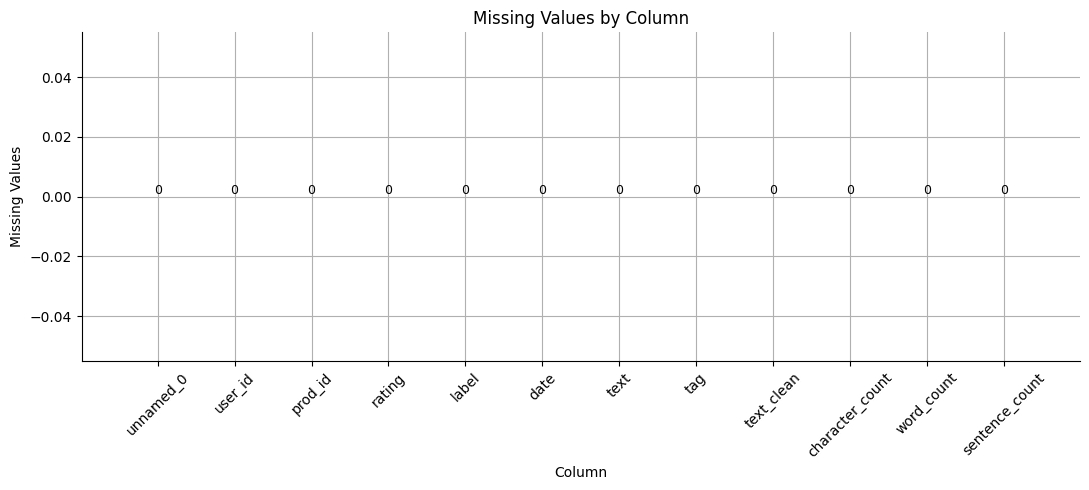

In [18]:
missing_plot_data = df.isna().sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 5))
#create the bar chart
bars = ax.bar(missing_plot_data.index.astype(str), missing_plot_data.values)
ax.set_title("Missing Values by Column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing Values")
ax.tick_params(axis="x", rotation=45)
add_bar_labels(ax, bars)
plt.tight_layout()
save_current_figure("missing_values")
plt.show()

### 16.Target Distribution Visualisation


shows the distribution of fake and geninw reviws before modelling.

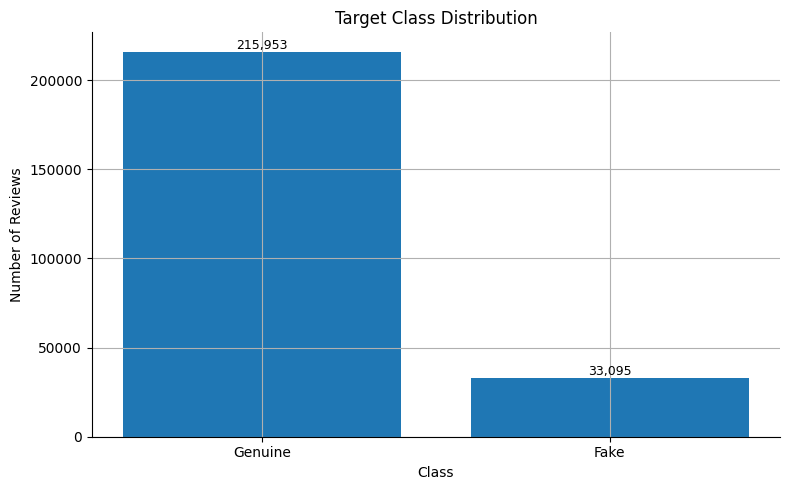

In [19]:
if target_col is not None:
    target_plot_data = df[target_col].value_counts().sort_index() #count each target class
    #Convert numerical class labels into meaningful names.
    target_plot_data.index = [class_names[int(value)] if class_names is not None and int(value) < len(class_names) else str(value) for value in target_plot_data.index]
else:
    target_plot_data = pd.Series({"Unlabelled": len(df)})
#plot the graph
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(target_plot_data.index.astype(str), target_plot_data.values)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Reviews")
add_bar_labels(ax, bars)
plt.tight_layout()
save_current_figure("target_distribution")
plt.show()

## 17.Rating Distribution Visualisation


hows how the reviews are distributed across different ratings.

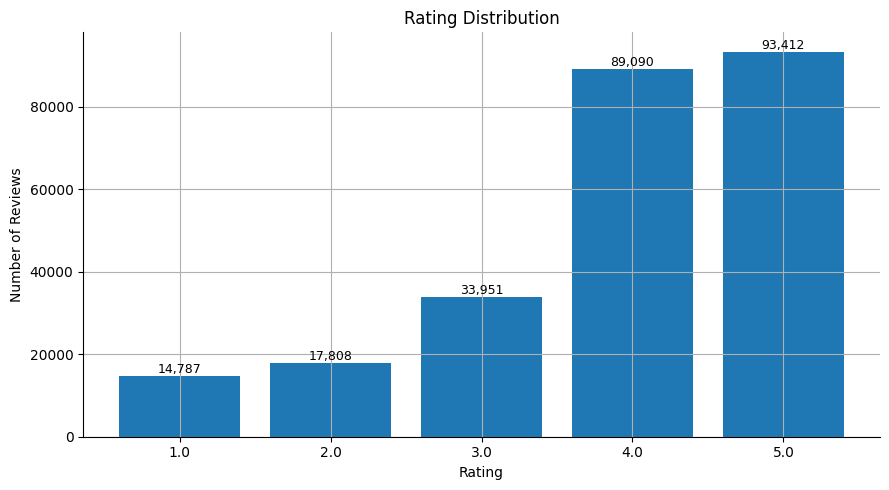

In [20]:
if rating_col is not None and rating_col in df.columns:
  #convert thr rating into numbers.
    rating_data = pd.to_numeric(df[rating_col], errors="coerce").dropna()
    if len(rating_data) > 0:
      #count how many times each raiting appers.
        rating_plot_data = rating_data.value_counts().sort_index()
    else:
        rating_plot_data = pd.Series({"No rating": len(df)})
else:
    rating_plot_data = pd.Series({"No rating column": len(df)})
# create graph
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rating_plot_data.index.astype(str), rating_plot_data.values)
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Reviews")
add_bar_labels(ax, bars)
plt.tight_layout()
save_current_figure("rating_distribution")
plt.show()

## 18.Word Count Visualisation

examine how many words are present in each review also check the length of the review text.

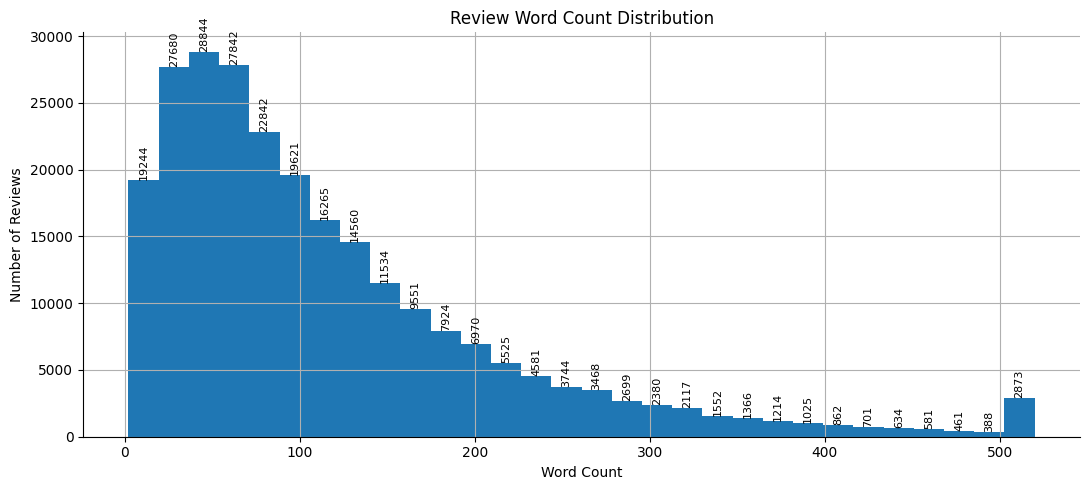

In [21]:
word_length_data = df["word_count"].clip(upper=df["word_count"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 5))
counts, bins, patches = ax.hist(word_length_data, bins=30)
ax.set_title("Review Word Count Distribution")
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Reviews")

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        ax.text((left + right) / 2, count, f"{int(count)}", ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
save_current_figure("word_count_distribution")
plt.show()

## 19.Character Count Visualisation



understand the length of the review texts in terms of characters. I used a histogram with 30 bins to show the distribution, and I limited the values at the 99th percentile so that extremely long reviews would not distort the visualisation

clean review text-count char-limit extre mevalue at 99th precentile- create histogram- divided in to 30 bins - add counts to bar and display

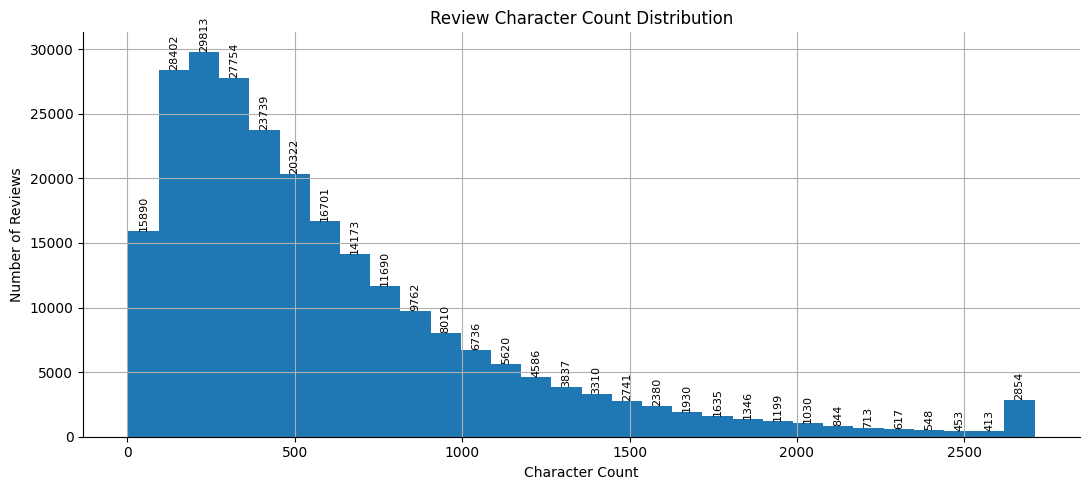

In [22]:
character_data = df["character_count"].clip(upper=df["character_count"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 5))
counts, bins, patches = ax.hist(character_data, bins=30) #create histrogram of review char count
ax.set_title("Review Character Count Distribution")
ax.set_xlabel("Character Count")
ax.set_ylabel("Number of Reviews")

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
      #put the count on the graph
        ax.text((left + right) / 2, count, f"{int(count)}", ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
save_current_figure("character_count_distribution")
plt.show()

## 20.Frequent Words Visualisation

identify the words that occur most often in the review dataset and remove the common stop words and very short words so that the visualisation focused on more meaningful terms."

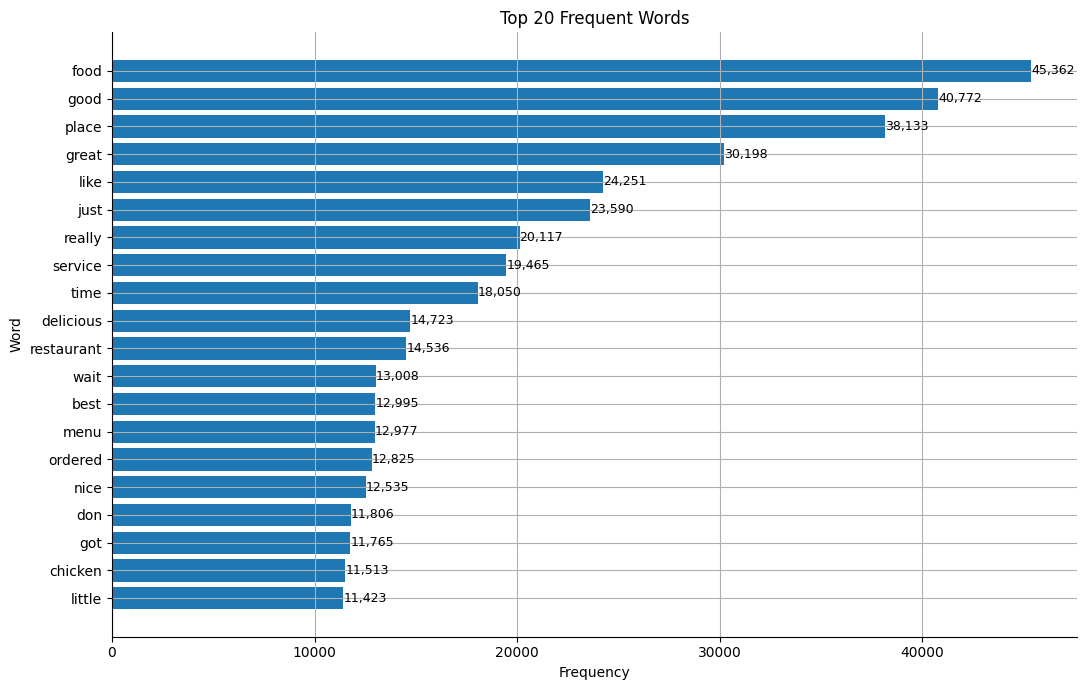

In [23]:
#take first 60,00 cleaned reviews,remove missing values,combines the text and split into individual tokens.
tokens = " ".join(df["text_clean"].dropna().astype(str).head(60000)).split()
#removes common words and shoter word than 3 char
filtered_tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS and len(word) > 2]
#find the top 20 words
top_words = pd.DataFrame(Counter(filtered_tokens).most_common(20), columns=["word", "count"])


fig, ax = plt.subplots(figsize=(11, 7))

if len(top_words) > 0:
    bars = ax.barh(top_words["word"][::-1], top_words["count"][::-1])
    ax.set_title("Top 20 Frequent Words")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")
    #add freqency number to the graph
    add_horizontal_bar_labels(ax, bars)
else:
    ax.text(0.5, 0.5, "No words available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("top_frequent_words")
plt.show()

## 21.Word Count by Class Visualisation

Find target classes--Separate reviews by class--Get word counts for each class---Limit extreme word counts-Create boxplot---Compare word---count distributions---Show median values

the boxplot to compare the distribution of review word counts between the different target classes. It allows to see the central tendency and spread of review lengths and compare the classes.



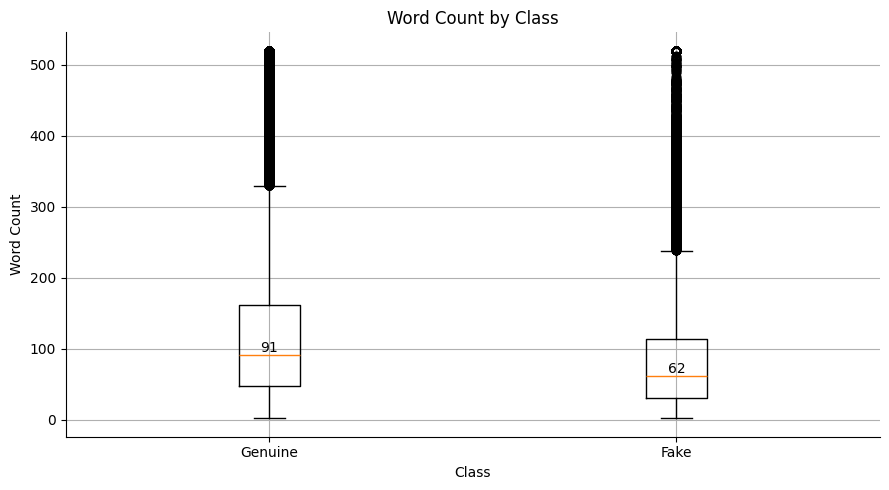

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

if target_col is not None: #check the target exit
    unique_targets = sorted(df[target_col].unique()) #find the different class.
    #get the word counts separately for each class
    box_data = [df.loc[df[target_col] == value, "word_count"].clip(upper=df["word_count"].quantile(0.99)) for value in unique_targets]
    labels = [class_names[int(value)] if class_names is not None and int(value) < len(class_names) else str(value) for value in unique_targets]
    #boxplot helps us see the distribution of word counts for each class.
    ax.boxplot(box_data, labels=labels)
    ax.set_title("Word Count by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Word Count")
    for index, values in enumerate(box_data, start=1):
        median_value = np.median(values) #finds the midium word count
        #display the medium on the graph
        ax.text(index, median_value, f"{median_value:.0f}", ha="center", va="bottom")
else:
    ax.text(0.5, 0.5, "Target label not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("word_count_by_class")
plt.show()

## 22.Rating by Class Visualisation

the reviews are grouped according to their target class using groupby(). Then mean() calculates the average rating for each class. Finally, a bar chart is created to compare the average ratings between the target classes.



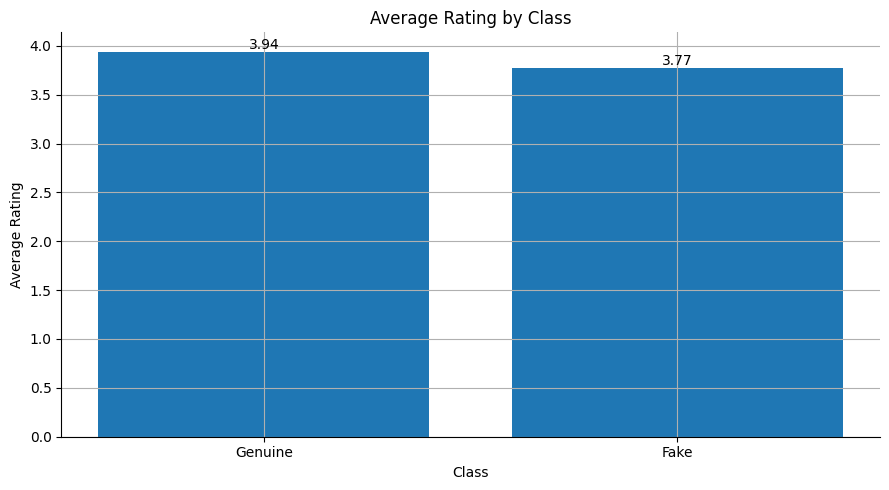

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

#continue if both the target and rating information are available
if target_col is not None and rating_col is not None and rating_col in df.columns:
    #converting rating into numbers
    rating_values = pd.to_numeric(df[rating_col], errors="coerce")
    #only valied numeric rating are kept.
    rating_class_data = df.assign(rating_numeric=rating_values).dropna(subset=["rating_numeric"])
    if len(rating_class_data) > 0:
        #calculating average rating for each class
        rating_summary = rating_class_data.groupby(target_col)["rating_numeric"].mean()
        #give the class meaningful names
        labels = [class_names[int(value)] if class_names is not None and int(value) < len(class_names) else str(value) for value in rating_summary.index]
        bars = ax.bar(labels, rating_summary.values)
        ax.set_title("Average Rating by Class")
        ax.set_xlabel("Class")
        ax.set_ylabel("Average Rating")
        #put the average value above each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom")
    else:
        ax.text(0.5, 0.5, "Rating values not available", ha="center", va="center")
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, "Rating or target column not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("average_rating_by_class")
plt.show()

## 23.Monthly Review Volume Visualisation


to analyse how the volume of reviews changes over time. The reviews are grouped by month and the number of reviews in each month is plotted as a line graph.

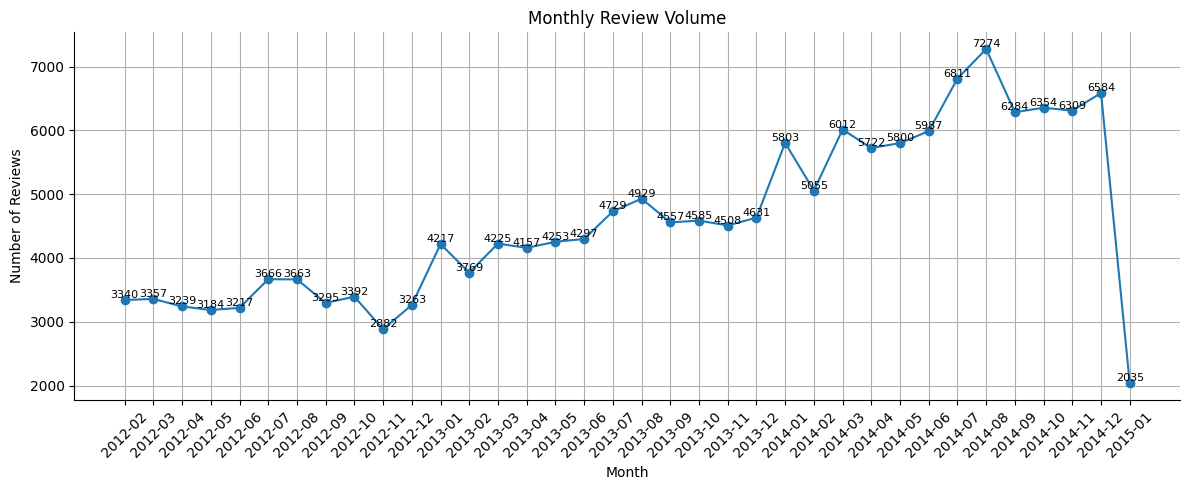

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

#checks whether a valid date column is available
if date_col is not None and date_col in df.columns:
    date_values = pd.to_datetime(df[date_col], errors="coerce")
    temporal_df = df.assign(review_date_parsed=date_values).dropna(subset=["review_date_parsed"])
    if len(temporal_df) > 0:
        #count reviws month by month
        monthly_reviews = temporal_df.set_index("review_date_parsed").resample("M").size().tail(36)
        ax.plot(monthly_reviews.index.strftime("%Y-%m"), monthly_reviews.values, marker="o")
        ax.set_title("Monthly Review Volume")
        ax.set_xlabel("Month")
        ax.set_ylabel("Number of Reviews")
        ax.tick_params(axis="x", rotation=45)
        #add the number above every point
        for x_value, y_value in zip(monthly_reviews.index.strftime("%Y-%m"), monthly_reviews.values):
            #write actual review count above the point
            ax.text(x_value, y_value, f"{int(y_value)}", ha="center", va="bottom", fontsize=8)
    else:
        ax.text(0.5, 0.5, "Valid date values not available", ha="center", va="center")
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, "Date column not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("monthly_review_volume")
plt.show()

## 24.Business Review Count Visualisation

 identify the top 15 businesses with the highest number of reviews and visualize their review counts using a horizontal bar chart. This helps to understand the distribution of reviews across businesses and identify which businesses are most represented in the dataset.

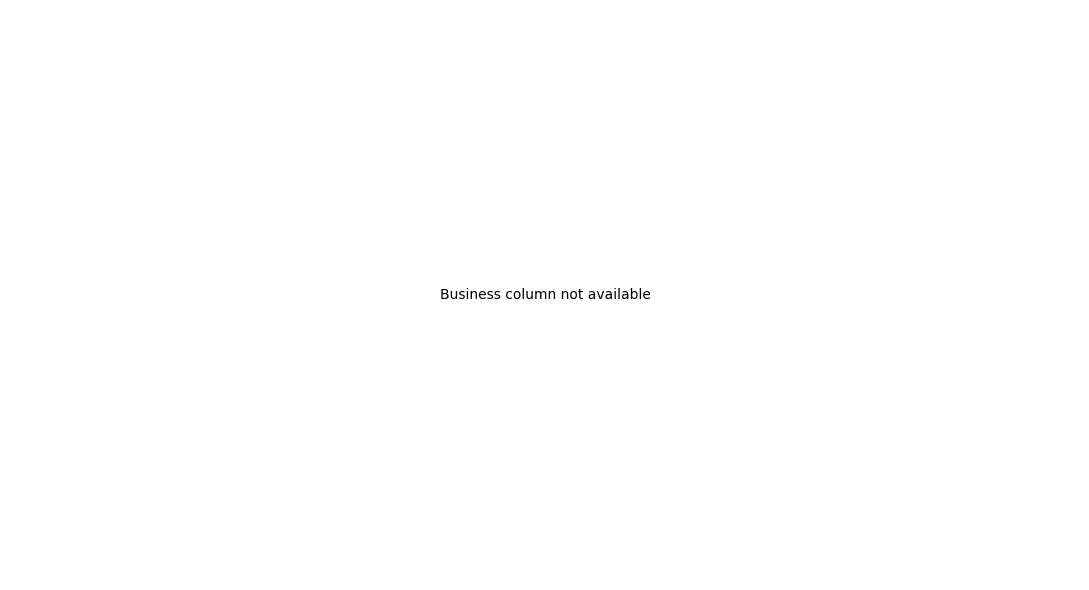

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
#checks wheather the business column exits.
if business_col is not None and business_col in df.columns:
    #counting reviews for each business
    business_counts = df[business_col].astype(str).value_counts().head(15)
    bars = ax.barh(business_counts.index[::-1], business_counts.values[::-1])
    ax.set_title("Top 15 Businesses by Review Count")
    ax.set_xlabel("Number of Reviews")
    ax.set_ylabel("Business")
    add_horizontal_bar_labels(ax, bars)
else:
    ax.text(0.5, 0.5, "Business column not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("top_business_review_count")
plt.show()

## 25.Correlation Visualisation

shows the relationships between numerical features such as review length, word count, sentence count, average word length, rating, and the target variable. The correlation heatmap provides a visual way to identify strong, weak, positive, or negative relationships between these variables.

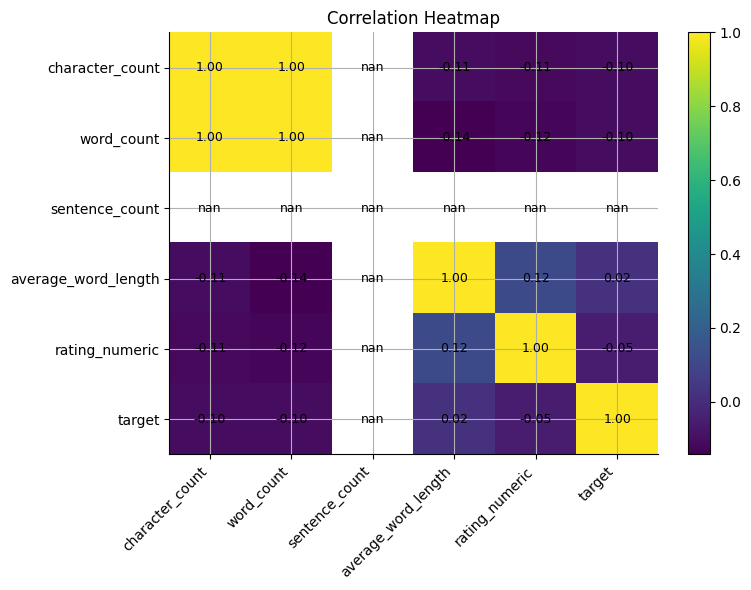

In [ ]:
#selecting the numerical columns
numeric_columns_for_corr = ["character_count", "word_count", "sentence_count", "average_word_length"]

if rating_col is not None and rating_col in df.columns:
    #converting ratings into numbers
    df["rating_numeric"] = pd.to_numeric(df[rating_col], errors="coerce")
    #adding the rating column to the list
    numeric_columns_for_corr.append("rating_numeric")
#If a target column exists, it is added to the list of columns used for correlation
if target_col is not None:
    numeric_columns_for_corr.append(target_col)
#select the column need to anlalyse and convert all selected colounms into numbers
corr_df = df[numeric_columns_for_corr].apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all")
#calculates the correlation between the numerical columns.
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
#check there is enough data,
if corr_matrix.shape[0] > 1:
    #create the heatmap
    image = ax.imshow(corr_matrix.values, aspect="auto")
    ax.set_title("Correlation Heatmap")
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix.columns)
    plt.colorbar(image, ax=ax)
    #check through every correlation value
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):

            #display the correlation values
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "Not enough numeric columns", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout() #adjust the layout
save_current_figure("correlation_heatmap")
plt.show()

## 26.Feature Dataset

a clean, organized feature dataset containing the important review-related features and any available optional information. It then produces a small summary showing the size of the dataset, number of features, whether a target variable is available, and the dataset mode.

In [ ]:
selected_columns = ["text_clean", "character_count", "word_count", "sentence_count", "average_word_length"]

for optional_column in [text_col, target_col, rating_col, date_col, reviewer_col, business_col]:
    if optional_column is not None and optional_column in df.columns and optional_column not in selected_columns:
        selected_columns.append(optional_column)
#creating the feature dataset which contains only the columns stored in selected_columns.
df_features = df[selected_columns].copy()
df_features = df_features.reset_index(drop=True)

feature_dataset_summary = pd.DataFrame({
    "metric": ["rows", "columns", "target_available", "dataset_mode"],
    "value": [df_features.shape[0], df_features.shape[1], target_col is not None, dataset_mode]
})

feature_dataset_summary

,metric,value
0,rows,249048
1,columns,10
2,target_available,True
3,dataset_mode,review_text


##27. Modelling Dataset

prepare the dataset for supervised machine learning by ensuring that a valid target variable and multiple classes are available, removing unsuitable records, balancing the number of samples where necessary, and creating a clean dataset ready for model training.

In [ ]:
#checking if the dataset is ready for supervised learning
#check the dataset has suitable target column for classification
ready_for_supervised = target_col is not None and df_features[target_col].nunique(dropna=True) >= 2

if ready_for_supervised:
  #remove the rows with missing target or text.
    df_model = df_features.dropna(subset=[target_col, "text_clean"]).copy()
    #remove empty reviews and convert to txt , remove space
    df_model = df_model[df_model["text_clean"].astype(str).str.strip().ne("")]
    #converts the target values into integers.
    df_model[target_col] = df_model[target_col].astype(int)

    class_counts = df_model[target_col].value_counts()
    number_of_classes = df_model[target_col].nunique()

    if len(df_model) > MODEL_SAMPLE_ROWS: #check the length of dataset
       #how many rows should be taken from each class.
        sample_per_class = max(MODEL_SAMPLE_ROWS // number_of_classes, 1)
        #grouping the dataset by class
        df_model = (
            df_model
            .groupby(target_col, group_keys=False)
            #take sample from each classes
            .apply(lambda group: group.sample(min(len(group), sample_per_class), random_state=RANDOM_STATE))
            #randomly mix the sampled rows
            .sample(frac=1, random_state=RANDOM_STATE)
            .reset_index(drop=True)
        )
else:
    df_model = df_features.copy()
    number_of_classes = 0

model_dataset_summary = pd.DataFrame({
    "metric": ["ready_for_supervised", "model_rows", "number_of_classes"],
    "value": [ready_for_supervised, len(df_model), number_of_classes]
})

model_dataset_summary

,metric,value
0,ready_for_supervised,True
1,model_rows,60000
2,number_of_classes,2


## 28.Train Test Split

In [ ]:
if ready_for_supervised:
  #cleaned review text that will be used as the input and output (target labels)to the ML model.
    X = df_model["text_clean"].astype(str)
    y = df_model[target_col].astype(int)
#Check whether each class has enough samples to maintain the same class proportions during the split.
    stratify_value = y if y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2, #20% data used for testing and 80% for training
        random_state=RANDOM_STATE,
        stratify=stratify_value #maintain the class distribution
    )
#shows how many rows are in each split
    split_summary = pd.DataFrame({
        "dataset": ["X_train", "X_test", "y_train", "y_test"],
        "rows": [len(X_train), len(X_test), len(y_train), len(y_test)]
    })
else:
    X_train = X_test = y_train = y_test = None
    split_summary = pd.DataFrame({"dataset": ["Supervised split not created"], "rows": [len(df_model)]})

split_summary

,dataset,rows
0,X_train,48000
1,X_test,12000
2,y_train,48000
3,y_test,12000


## 29.TF-IDF Preparation

TF-IDF is a technique used to convert text into numerical features. It gives higher importance to words that are important to a particular document but less common across the whole collection of documents.

In [ ]:
if ready_for_supervised:
  #controls how rarely a word can occure before it is included as a feature
    minimum_df = 1 if len(X_train) < 1000 else 2
    #convert text in to numarical representation
    tfidf_vectorizer = TfidfVectorizer(
        max_features=30000,
        #use both single and multi word combination
        ngram_range=(1, 2),
        min_df=minimum_df,
        max_df=0.95
    )
#fit TF-IDF only on the training data and use transform on the test data to avoid data leakage
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    #converts the test reviews into the same numerical TF-IDF representation.
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    tfidf_summary = pd.DataFrame({
        "item": ["training_rows", "testing_rows", "tfidf_features"],
        "value": [X_train_tfidf.shape[0], X_test_tfidf.shape[0], X_train_tfidf.shape[1]]
    })
else:
    tfidf_vectorizer = None
    X_train_tfidf = X_test_tfidf = None
    tfidf_summary = pd.DataFrame({"item": ["tfidf_status"], "value": ["not available"]})

tfidf_summary

,item,value
0,training_rows,48000
1,testing_rows,12000
2,tfidf_features,30000


## 30.Evaluation Functions

In [ ]:
def metric_average(y_true):
    return "binary" if len(np.unique(y_true)) == 2 else "weighted"

def prepare_score_for_auc(y_score):#prediction score
    if y_score is None:
        return None
        #conveerts the score in to numpy array
    score_array = np.asarray(y_score)
    if score_array.ndim == 2 and score_array.shape[1] == 2:
        return score_array[:, 1]
    return score_array

def calculate_metrics(model_name, y_true, y_pred, y_score=None):
    average_method = metric_average(y_true)
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average_method, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average_method, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average=average_method, zero_division=0)
    }

    try:
        score_values = prepare_score_for_auc(y_score)
        if score_values is not None and len(np.unique(y_true)) == 2:
            metrics["roc_auc"] = roc_auc_score(y_true, score_values)
        else:
            metrics["roc_auc"] = np.nan
    except Exception:
        metrics["roc_auc"] = np.nan

    return metrics

def get_model_score(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)
    if hasattr(model, "decision_function"):
        return model.decision_function(X_values)
    return None

## 31.Traditional Machine Learning Models

Trains and evaluates three models:
Logistic Regression, Naive Bayes, and Linear SVM using the TF-IDF features to classify reviews into their target classes.

In [ ]:
#create the empty storage and empty list to store the results
traditional_models_fitted = {}
traditional_results = []

if ready_for_supervised:
    traditional_models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
        "Naive Bayes": MultinomialNB(),
        "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
    }
#goes through each traditional model one by one so that the same training and evaluation process can be applied to all models.
    for model_name, model in traditional_models.items():
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)
        #store the prediction score
        y_score = get_model_score(model, X_test_tfidf)
        #calculate evalution metrics
        traditional_results.append(calculate_metrics(model_name, y_test, y_pred, y_score))
        #stored the trained model
        traditional_models_fitted[model_name] = model

traditional_metrics_df = pd.DataFrame(traditional_results)
traditional_metrics_df

NameError: name 'ready_for_supervised' is not defined

## 32.Traditional Model Metrics Visualisation

visualises and compares the performance of the three traditional machine-learning models using accuracy, precision, recall, and F1-score."

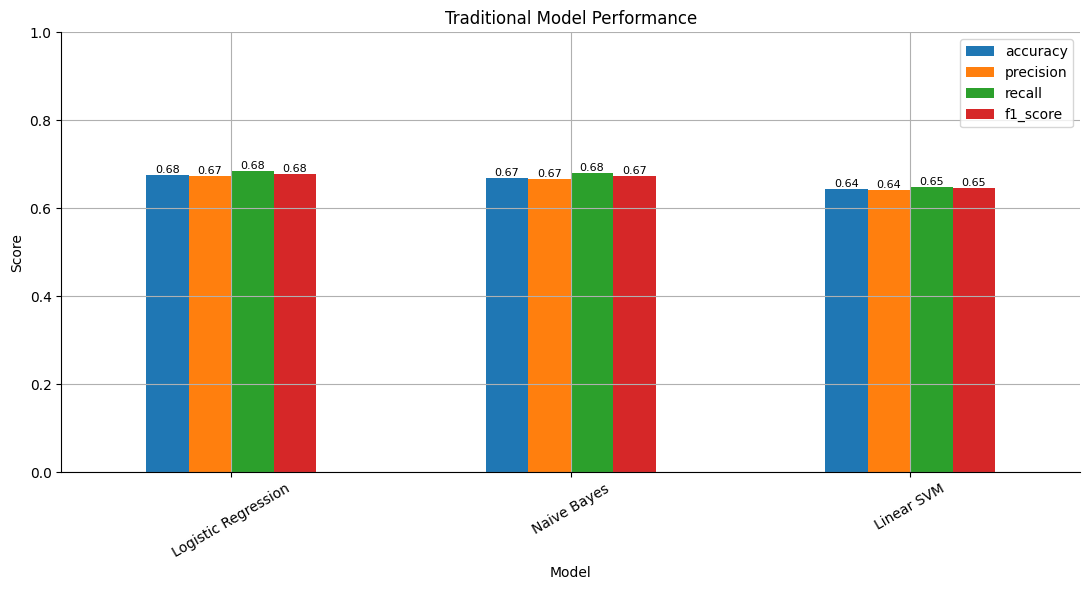

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

if len(traditional_metrics_df) > 0:
    plot_data = traditional_metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]]
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title("Traditional Model Performance")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)
else:
    ax.text(0.5, 0.5, "Traditional model results not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("traditional_model_performance")
plt.show()

## 33.Sequence Preparation

converts the cleaned reviews into numerical sequences using a tokenizer and pads or truncates them to a fixed length of 180 so they can be used as input to the RNN and Bi-LSTM models.

In [ ]:
if ready_for_supervised and tf is not None:
    MAX_WORDS = 30000
    MAX_SEQUENCE_LENGTH = 180
#create the tokenizer which convert words into numbers
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    #learuns the vocabulary ans assign  the numerical indices based on the training text.
    tokenizer.fit_on_texts(X_train.astype(str))

    #convert the training text into sequences
    X_train_seq = tokenizer.texts_to_sequences(X_train.astype(str))
    X_test_seq = tokenizer.texts_to_sequences(X_test.astype(str))

    #make the review sequence same length of 180 by adding padding
    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")


    vocabulary_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

    sequence_summary = pd.DataFrame({
        "item": ["training_sequences", "testing_sequences", "vocabulary_size", "sequence_length"],
        "value": [X_train_pad.shape[0], X_test_pad.shape[0], vocabulary_size, MAX_SEQUENCE_LENGTH]
    })
else:
    MAX_WORDS = None
    MAX_SEQUENCE_LENGTH = None
    tokenizer = None
    X_train_pad = X_test_pad = None
    vocabulary_size = 0
    sequence_summary = pd.DataFrame({"item": ["sequence_status"], "value": ["not available"]})

sequence_summary

,item,value
0,training_sequences,48000
1,testing_sequences,12000
2,vocabulary_size,30000
3,sequence_length,180


##34. Deep Learning Settings

defines the main training parameters: 5 epochs, a batch size of 128, an embedding dimension of 128, and class weights for the target classes.

In [ ]:
if ready_for_supervised and tf is not None:
    y_train_array = y_train.values.astype(int)
    y_test_array = y_test.values.astype(int)

    unique_classes = np.unique(y_train_array)
    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=unique_classes,
        y=y_train_array
    )

    class_weight_dict = {int(class_label): float(weight) for class_label, weight in zip(unique_classes, class_weights_array)}

    EPOCHS = 5  #5 times the training data goes through mode
    BATCH_SIZE = 128
    EMBEDDING_DIM = 128 #size of numrical vector used to reprent each word

    deep_learning_summary = pd.DataFrame({
        "setting": ["epochs", "batch_size", "embedding_dim", "class_weights"],
        "value": [EPOCHS, BATCH_SIZE, EMBEDDING_DIM, class_weight_dict]
    })
else:
    y_train_array = y_test_array = None
    class_weight_dict = {}
    EPOCHS = 0
    BATCH_SIZE = 0
    EMBEDDING_DIM = 0
    deep_learning_summary = pd.DataFrame({"setting": ["deep_learning_status"], "value": ["not available"]})

deep_learning_summary

,setting,value
0,epochs,5
1,batch_size,128
2,embedding_dim,128
3,class_weights,"{0: 1.0, 1: 1.0}"


##35. RNN Model

The RNN model uses an Embedding layer to represent words numerically, a SimpleRNN layer to learn sequential patterns, dropout layers to reduce overfitting, and a Dense sigmoid output layer to classify the reviews into two classes.

In [ ]:
def build_rnn_model(vocab_size, sequence_length, embedding_dim, number_of_classes):
    model = Sequential()

    #converts the integer word sequences into dense numerical vectors
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length))
    #reduce the overfiting
    model.add(SpatialDropout1D(0.2))
    model.add(SimpleRNN(64))
    model.add(Dropout(0.3))

    if number_of_classes == 2:
      #converts the output into a value between 0 and 1
        model.add(Dense(1, activation="sigmoid"))
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    else:
        model.add(Dense(number_of_classes, activation="softmax"))
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

if ready_for_supervised and tf is not None:
    rnn_model = build_rnn_model(vocabulary_size, MAX_SEQUENCE_LENGTH, EMBEDDING_DIM, number_of_classes)
    rnn_model.summary()
else:
    rnn_model = None

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 36.RNN Training

Train the RNN using the prepared training sequences and monitor its performance during training

The RNN is trained using the padded training sequences and labels, with 20% of the training data used for validation, while EarlyStopping and ReduceLROnPlateau help control overfitting and improve the training process.

In [ ]:
if rnn_model is not None:
    rnn_callbacks = [
        #montiores validation loss and stop training if it does not improve for two epochs.whilerestorinh the best model weights.
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", patience=1, factor=0.5)
    ]
    #stores the information abut training process such as loss,accurecy over the epochs
    rnn_history = rnn_model.fit(
        X_train_pad,
        y_train_array,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=rnn_callbacks,
        verbose=1
    )
else:
    rnn_history = None

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5368 - loss: 0.6887 - val_accuracy: 0.5529 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5587 - loss: 0.6702 - val_accuracy: 0.5523 - val_loss: 0.6875 - learning_rate: 0.0010
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6061 - loss: 0.6297 - val_accuracy: 0.5485 - val_loss: 0.6969 - learning_rate: 5.0000e-04


##37. RNN Evaluation

Use the trained RNN to make predictions on the test data and calculate its performance metrics


predictions on the test data, converts the prediction scores into binary classes using a 0.5 threshold, and calculates performance metrics by comparing them with the actual test labels.

In [ ]:
deep_results = []

if rnn_model is not None:
  #make predictions
    rnn_prediction_raw = rnn_model.predict(X_test_pad, verbose=0)

    if number_of_classes == 2:
      #converts the prediction output into a simple one-dimensional array of scores.
        rnn_scores = rnn_prediction_raw.reshape(-1)
        #Threshold of 0.5 is used to convert the RNN prediction scores into class 0 or class 1
        rnn_predictions = (rnn_scores >= 0.5).astype(int)
    else:
        rnn_scores = rnn_prediction_raw
        rnn_predictions = np.argmax(rnn_prediction_raw, axis=1)

    deep_results.append(calculate_metrics("RNN", y_test_array, rnn_predictions, rnn_scores))

rnn_metrics_df = pd.DataFrame([result for result in deep_results if result["model"] == "RNN"])
rnn_metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,RNN,0.554583,0.533476,0.869833,0.661344,0.559228


## 38.Bi-LSTM Model
The Bi-LSTM model is similar to the RNN but replaces the SimpleRNN layer with a Bidirectional LSTM, allowing the model to learn information from both forward and backward directions in the review sequence

In [ ]:
def build_bilstm_model(vocab_size, sequence_length, embedding_dim, number_of_classes):
    model = Sequential()

    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length))
    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.4))
    #processes the features learned by the Bi-LSTM
    model.add(Dense(64, activation="relu"))#Creates a fully connected layer with 64 units.
    model.add(Dropout(0.3))

    if number_of_classes == 2:
        model.add(Dense(1, activation="sigmoid"))
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    else:
        model.add(Dense(number_of_classes, activation="softmax"))
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

if ready_for_supervised and tf is not None:
    bilstm_model = build_bilstm_model(vocabulary_size, MAX_SEQUENCE_LENGTH, EMBEDDING_DIM, number_of_classes)
    bilstm_model.summary()
else:
    bilstm_model = None

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 39.Bi-LSTM Training

The Bi-LSTM is trained using the padded training sequences and labels, with 20% validation data, while EarlyStopping and ReduceLROnPlateau are used to control the training process and reduce overfitting.

In [ ]:
if bilstm_model is not None:
    bilstm_callbacks = [
        #stops training when the validation loss stops improving and keeps the best weights.
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        #The model make smaller learning steps when improvement slows down.
        ReduceLROnPlateau(monitor="val_loss", patience=1, factor=0.5)
    ]

    #traon the Bi-lstm
    bilstm_history = bilstm_model.fit(
        X_train_pad,
        y_train_array,#correct the taget class
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=bilstm_callbacks,
        verbose=1
    )
else:
    bilstm_history = None

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.6346 - loss: 0.6386 - val_accuracy: 0.6655 - val_loss: 0.6130 - learning_rate: 0.0010
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.6999 - loss: 0.5784 - val_accuracy: 0.6636 - val_loss: 0.6196 - learning_rate: 0.0010
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7580 - loss: 0.5041 - val_accuracy: 0.6445 - val_loss: 0.6579 - learning_rate: 5.0000e-04


## 40.Bi-LSTM Evaluation

the trained model predicts the test sequences, the prediction scores are converted into binary classes using a 0.5 threshold, and the predicted classes and scores are compared with the actual test labels to calculate Accuracy, Precision, Recall, F1-score and ROC-AUC

In [ ]:
if bilstm_model is not None:
    bilstm_prediction_raw = bilstm_model.predict(X_test_pad, verbose=0)

    if number_of_classes == 2:
        bilstm_scores = bilstm_prediction_raw.reshape(-1)
        bilstm_predictions = (bilstm_scores >= 0.5).astype(int)
    else:
        bilstm_scores = bilstm_prediction_raw
        bilstm_predictions = np.argmax(bilstm_prediction_raw, axis=1)

    deep_results.append(calculate_metrics("Bi-LSTM", y_test_array, bilstm_predictions, bilstm_scores))

bilstm_metrics_df = pd.DataFrame([result for result in deep_results if result["model"] == "Bi-LSTM"])
bilstm_metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Bi-LSTM,0.66625,0.643877,0.744,0.690327,0.727889


## 41.Combined Results
combines the traditional machine-learning and deep-learning evaluation results into one final DataFrame, sorts all models by F1-score from highest to lowest, and displays the final performance comparison.

In [ ]:
deep_metrics_df = pd.DataFrame(deep_results)

metrics_frames = []
#If the results table contains at least one model, create the graph.
if len(traditional_metrics_df) > 0:
    metrics_frames.append(traditional_metrics_df)

if len(deep_metrics_df) > 0:
    metrics_frames.append(deep_metrics_df)

if len(metrics_frames) > 0:
  #combine the result tables into a final dataframe
    final_metrics_df = pd.concat(metrics_frames, ignore_index=True)
    final_metrics_df = final_metrics_df.sort_values("f1_score", ascending=False).reset_index(drop=True)
else:
    final_metrics_df = pd.DataFrame(columns=["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"])

final_metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Bi-LSTM,0.666250,0.643877,0.744000,0.690327,0.727889
1,Logistic Regression,0.675333,0.672402,0.683833,0.678070,0.742322
2,Naive Bayes,0.668917,0.665578,0.679000,0.672222,0.731729
3,RNN,0.554583,0.533476,0.869833,0.661344,0.559228
4,Linear SVM,0.642833,0.641093,0.649000,0.645022,0.699238


## 42.Combined Metrics Visualisation
creates a bar chart to compare the Accuracy, Precision, Recall and F1-score of all the models. It adds the values to the bars, formats the graph for readability, saves the figure and displays it

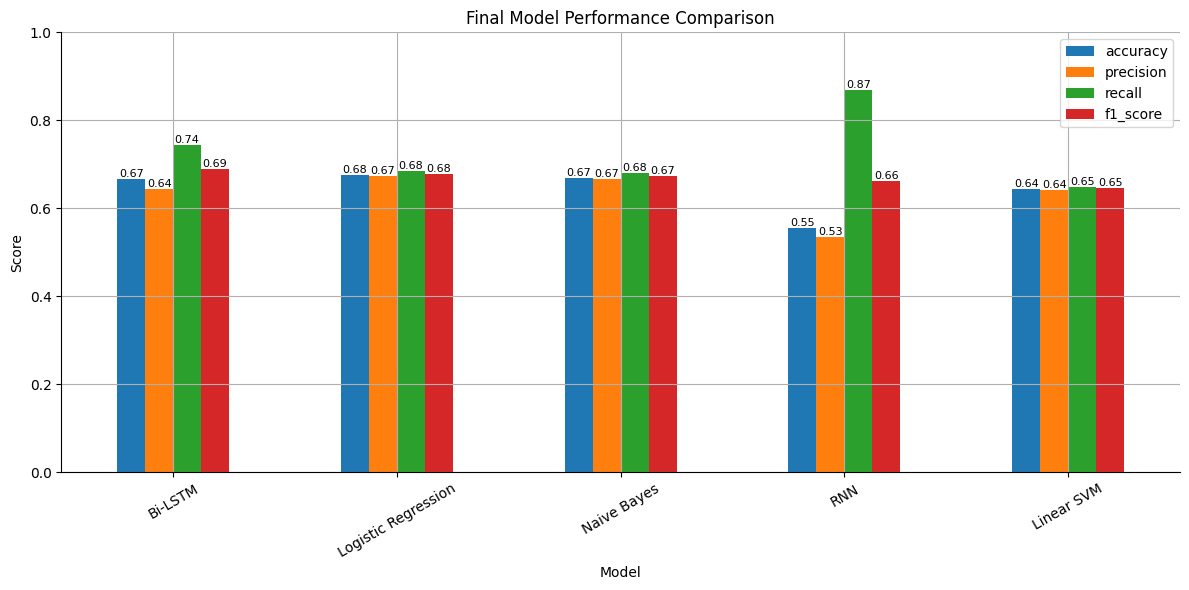

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

if len(final_metrics_df) > 0:
    plot_data = final_metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]]
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title("Final Model Performance Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)
else:
    ax.text(0.5, 0.5, "Final metrics not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("final_model_performance")
plt.show()

## 43.Confusion Matrix Visualisation
function to create and display confusion matrices. It compares actual and predicted labels and shows the values for each class. It then creates confusion matrices for the best Traditional ML model, RNN, and Bi-LSTM so their classification errors can be visually analysed

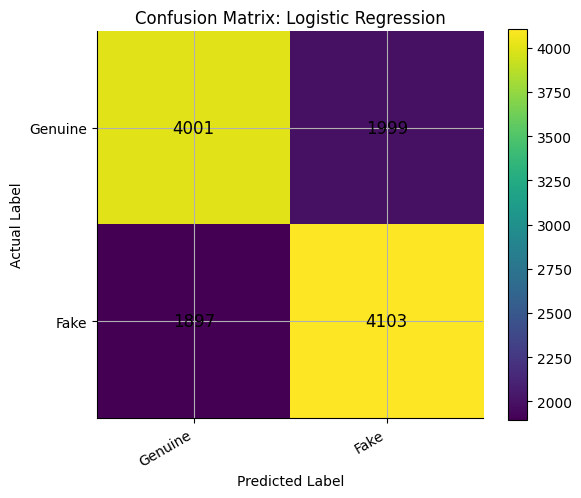

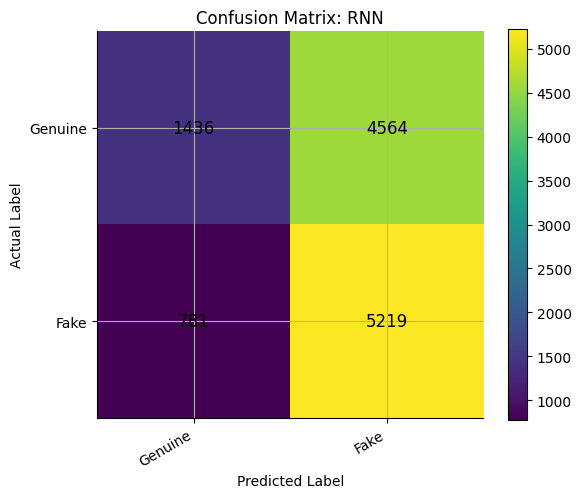

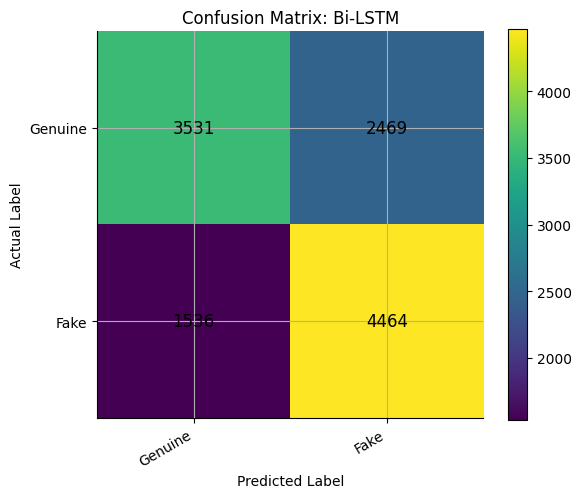

In [ ]:
def plot_confusion_matrix_values(y_true, y_pred, title, file_name):
    matrix = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    tick_labels = class_names if class_names is not None and len(class_names) == matrix.shape[0] else [str(i) for i in range(matrix.shape[0])]
    ax.set_xticks(range(matrix.shape[0]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(tick_labels, rotation=30, ha="right")
    ax.set_yticklabels(tick_labels)
    plt.colorbar(image, ax=ax)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]}", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    save_current_figure(file_name)
    plt.show()

if ready_for_supervised and len(final_metrics_df) > 0:
    best_traditional_name = traditional_metrics_df.sort_values("f1_score", ascending=False).iloc[0]["model"] if len(traditional_metrics_df) > 0 else None

    if best_traditional_name is not None:
        best_traditional_model = traditional_models_fitted[best_traditional_name]
        best_traditional_predictions = best_traditional_model.predict(X_test_tfidf)
        plot_confusion_matrix_values(y_test, best_traditional_predictions, f"Confusion Matrix: {best_traditional_name}", "confusion_matrix_best_traditional")

    if "rnn_predictions" in globals():
        plot_confusion_matrix_values(y_test_array, rnn_predictions, "Confusion Matrix: RNN", "confusion_matrix_rnn")

    if "bilstm_predictions" in globals():
        plot_confusion_matrix_values(y_test_array, bilstm_predictions, "Confusion Matrix: Bi-LSTM", "confusion_matrix_bilstm")

## 44.ROC Curve Visualisation

compare the ability of different classification models, including traditional machine-learning models, RNN, and Bi-LSTM, to distinguish between the two target classes. The ROC curves visualize the trade-off between the True Positive Rate and False Positive Rate, helping to assess and compare the classification performance of the models

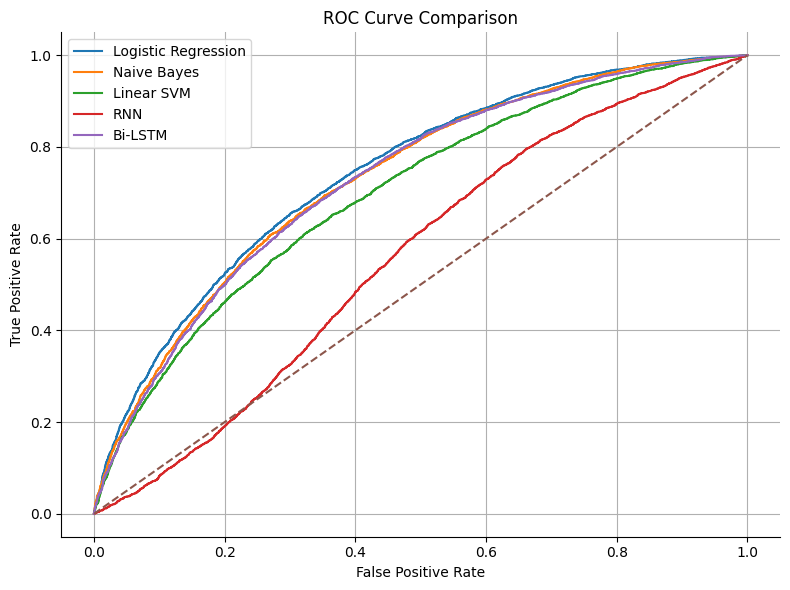

In [ ]:
#Check for binary classification → Get model prediction scores → Calculate ROC → Plot each model → Add random baseline → Compare the curves

fig, ax = plt.subplots(figsize=(8, 6))

roc_available = False


if ready_for_supervised and number_of_classes == 2:
    for model_name, model in traditional_models_fitted.items():
        y_score = get_model_score(model, X_test_tfidf)
        y_score = prepare_score_for_auc(y_score)
        if y_score is not None:
            fpr, tpr, thresholds = roc_curve(y_test, y_score)
            ax.plot(fpr, tpr, label=model_name)
            roc_available = True

    if "rnn_scores" in globals():
        fpr, tpr, thresholds = roc_curve(y_test_array, rnn_scores)
        ax.plot(fpr, tpr, label="RNN")
        roc_available = True

    if "bilstm_scores" in globals():
        fpr, tpr, thresholds = roc_curve(y_test_array, bilstm_scores)
        ax.plot(fpr, tpr, label="Bi-LSTM")
        roc_available = True

if roc_available:
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title("ROC Curve Comparison")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
else:
    ax.text(0.5, 0.5, "ROC curve not available", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout()
save_current_figure("roc_curve_comparison")
plt.show()

## 45.Training Curve Visualisation
isualize the training and validation accuracy of the RNN and Bi-LSTM models across different epochs. The plots help evaluate how the models learn during training and identify potential issues such as overfitting by comparing training and validation performance.

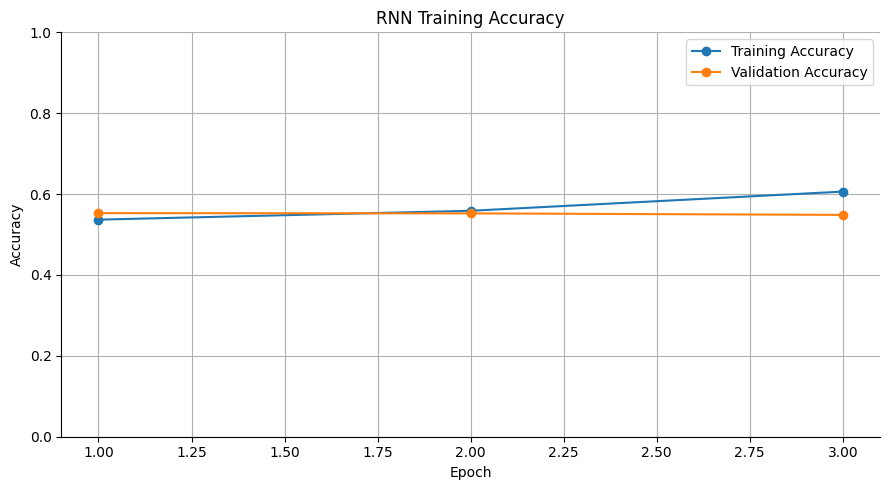

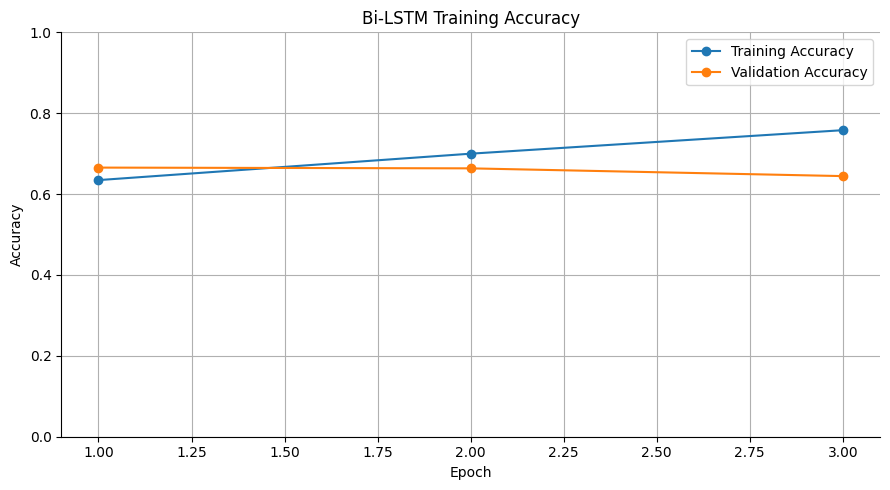

In [ ]:
def plot_training_history(history, title, file_name):
    fig, ax = plt.subplots(figsize=(9, 5))
    if history is not None:
        history_df = pd.DataFrame(history.history)
        if "accuracy" in history_df.columns:
            ax.plot(history_df.index + 1, history_df["accuracy"], marker="o", label="Training Accuracy")
        if "val_accuracy" in history_df.columns:
            ax.plot(history_df.index + 1, history_df["val_accuracy"], marker="o", label="Validation Accuracy")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Training history not available", ha="center", va="center")
        ax.set_axis_off()
    plt.tight_layout()
    save_current_figure(file_name)
    plt.show()

plot_training_history(rnn_history if "rnn_history" in globals() else None, "RNN Training Accuracy", "rnn_training_accuracy")
plot_training_history(bilstm_history if "bilstm_history" in globals() else None, "Bi-LSTM Training Accuracy", "bilstm_training_accuracy")

##46. Classification Reports

evaluate the performance of the trained classification models using classification reports. It calculates precision, recall, F1-score, accuracy, and support for the best traditional model, RNN, and Bi-LSTM, allowing their classification performance to be compared

In [ ]:
classification_reports = {}

if ready_for_supervised:
    if "best_traditional_predictions" in globals() and best_traditional_name is not None:
        classification_reports[best_traditional_name] = classification_report(y_test, best_traditional_predictions, zero_division=0)

    if "rnn_predictions" in globals():
        classification_reports["RNN"] = classification_report(y_test_array, rnn_predictions, zero_division=0)

    if "bilstm_predictions" in globals():
        classification_reports["Bi-LSTM"] = classification_report(y_test_array, bilstm_predictions, zero_division=0)

for report_name, report_text in classification_reports.items():
    print(report_name)
    print(report_text)

Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      6000
           1       0.67      0.68      0.68      6000

    accuracy                           0.68     12000
   macro avg       0.68      0.68      0.68     12000
weighted avg       0.68      0.68      0.68     12000

RNN
              precision    recall  f1-score   support

           0       0.65      0.24      0.35      6000
           1       0.53      0.87      0.66      6000

    accuracy                           0.55     12000
   macro avg       0.59      0.55      0.51     12000
weighted avg       0.59      0.55      0.51     12000

Bi-LSTM
              precision    recall  f1-score   support

           0       0.70      0.59      0.64      6000
           1       0.64      0.74      0.69      6000

    accuracy                           0.67     12000
   macro avg       0.67      0.67      0.66     12000
weighted avg       0.67      0.67      0.6

## 47.Best Model Selection

In [ ]:
if len(final_metrics_df) > 0:
    best_model_name = final_metrics_df.iloc[0]["model"]
else:
    best_model_name = None

best_model_summary = pd.DataFrame({
    "item": ["best_model"],
    "value": [best_model_name]
})

best_model_summary

,item,value
0,best_model,Bi-LSTM


## 48.Prediction Function
Create a prediction function that can classify a new, unseen review using the best-performing trained model. It applies the same preprocessing used during training, generates the appropriate input format for traditional, RNN, or Bi-LSTM models, and returns the predicted class along with the model used and its confidence score.

In [ ]:
#New review → Clean text → Convert to model format → Use best model → Predict class → Calculate confidence → Display result

def predict_review(review_text):
    if best_model_name is None:
        return pd.DataFrame({"message": ["No trained model available"]})

    clean_value = clean_text(review_text)

    if best_model_name in traditional_models_fitted:
        model = traditional_models_fitted[best_model_name]
        vector = tfidf_vectorizer.transform([clean_value])
        prediction = int(model.predict(vector)[0])
        score = get_model_score(model, vector)
        score = prepare_score_for_auc(score)
        confidence = float(score[0]) if score is not None and np.asarray(score).ndim == 1 else np.nan

    elif best_model_name == "RNN" and rnn_model is not None:
        sequence = tokenizer.texts_to_sequences([clean_value])
        padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
        raw_prediction = rnn_model.predict(padded, verbose=0)
        if number_of_classes == 2:
            confidence = float(raw_prediction.reshape(-1)[0])
            prediction = int(confidence >= 0.5)
        else:
            prediction = int(np.argmax(raw_prediction, axis=1)[0])
            confidence = float(np.max(raw_prediction))

    elif best_model_name == "Bi-LSTM" and bilstm_model is not None:
        sequence = tokenizer.texts_to_sequences([clean_value])
        padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
        raw_prediction = bilstm_model.predict(padded, verbose=0)
        if number_of_classes == 2:
            confidence = float(raw_prediction.reshape(-1)[0])
            prediction = int(confidence >= 0.5)
        else:
            prediction = int(np.argmax(raw_prediction, axis=1)[0])
            confidence = float(np.max(raw_prediction))

    else:
        return pd.DataFrame({"message": ["Best model object not available"]})

    label = class_names[prediction] if class_names is not None and prediction < len(class_names) else str(prediction)

    return pd.DataFrame({
        "review": [review_text],
        "cleaned_review": [clean_value],
        "best_model": [best_model_name],
        "predicted_class": [label],
        "confidence_score": [round(confidence, 4) if pd.notna(confidence) else confidence]
    })

sample_review = "The food was excellent and the service was very quick. I would visit again."
predict_review(sample_review)

,review,cleaned_review,best_model,predicted_class,confidence_score
0,The food was excellent and the service was very quick. I would visit again.,the food was excellent and the service was very quick i would visit again,Bi-LSTM,Fake,0.7435


## 49.Save Outputs

In [ ]:
cleaned_data_path = processed_dir / "cleaned_yelp_reviews.csv"
model_data_path = processed_dir / "model_ready_yelp_reviews.csv"
metrics_path = processed_dir / "final_model_metrics.csv"
profile_path = processed_dir / "final_data_profile.csv"

df_features.to_csv(cleaned_data_path, index=False)
df_model.to_csv(model_data_path, index=False)
final_metrics_df.to_csv(metrics_path, index=False)
final_profile.to_csv(profile_path, index=False)

if tfidf_vectorizer is not None:
    with open(model_dir / "tfidf_vectorizer.pkl", "wb") as file:
        pickle.dump(tfidf_vectorizer, file)

if len(traditional_models_fitted) > 0:
    with open(model_dir / "traditional_models.pkl", "wb") as file:
        pickle.dump(traditional_models_fitted, file)

if tokenizer is not None:
    with open(model_dir / "tokenizer.pkl", "wb") as file:
        pickle.dump(tokenizer, file)

if rnn_model is not None:
    rnn_model.save(model_dir / "rnn_model.keras")

if bilstm_model is not None:
    bilstm_model.save(model_dir / "bilstm_model.keras")

saved_outputs = pd.DataFrame({
    "path": [str(path) for path in list(processed_dir.iterdir()) + list(model_dir.iterdir()) + list(figure_dir.iterdir())]
})

saved_outputs

,path
0,/content/yelp_fake_review_project/processed/final_model_metrics.csv
1,/content/yelp_fake_review_project/processed/model_ready_yelp_reviews.csv
2,/content/yelp_fake_review_project/processed/final_data_profile.csv
3,/content/yelp_fake_review_project/processed/cleaned_yelp_reviews.csv
4,/content/yelp_fake_review_project/models/bilstm_model.keras
5,/content/yelp_fake_review_project/models/tokenizer.pkl
6,/content/yelp_fake_review_project/models/traditional_models.pkl
7,/content/yelp_fake_review_project/models/tfidf_vectorizer.pkl
8,/content/yelp_fake_review_project/models/rnn_model.keras
9,/content/yelp_fake_review_project/figures/rating_distribution.png


## 50.Final Summary

In [ ]:
final_summary = pd.DataFrame({
    "item": [
        "dataset_mode",
        "selected_file",
        "rows_used",
        "target_available",
        "number_of_classes",
        "best_model",
        "figures_saved",
        "processed_files_saved"
    ],
    "value": [
        dataset_mode,
        str(selected_file),
        len(df_model),
        ready_for_supervised,
        number_of_classes,
        best_model_name,
        len(list(figure_dir.iterdir())),
        len(list(processed_dir.iterdir()))
    ]
})

final_summary

,item,value
0,dataset_mode,review_text
1,selected_file,/content/yelp_fake_review_project/raw/yelpzip.csv
2,rows_used,60000
3,target_available,True
4,number_of_classes,2
5,best_model,Bi-LSTM
6,figures_saved,19
7,processed_files_saved,4
